# Real Estate Investment Advisor

## Objective:
To build a machine learning-powered decision support system that helps users:

- Identify whether a property is a good investments opportunity
- Predict future property prices after 5 years
- Analyze real estate market trends across India
- Support investors with ROI-based decision making

### Project Type:
End-to-End Data Science + Machine Learning + Streamlit Deployment

### Developed By:
Divyanshi Dhuliya


# Problem Statement

Real estate investment decisions are often based on incoplete information and this project aims to use historical housing data and machine learning models to

- Predict profitable investment opportunities
- Forecast future prices
- Provide data-driven investment recommendations
- Tmprove investor decision confidence

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
df = pd.read_csv("../data/raw/india_housing_prices.csv")
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


# Data Understanding
We first inspect the structure, shape, columns, missing values, and statistical summary of the dataset.

In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Dataset Shape: (250000, 23)

Columns:
 ['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  str    
 2   City                            250000 non-null  str    
 3   Locality                        250000 non-null  str    
 4   Property_Type                   250000 non-null  str    
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  str    
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors               

In [6]:
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


# Missing Value Analysis

In [7]:
df.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Distribution of Property Prices

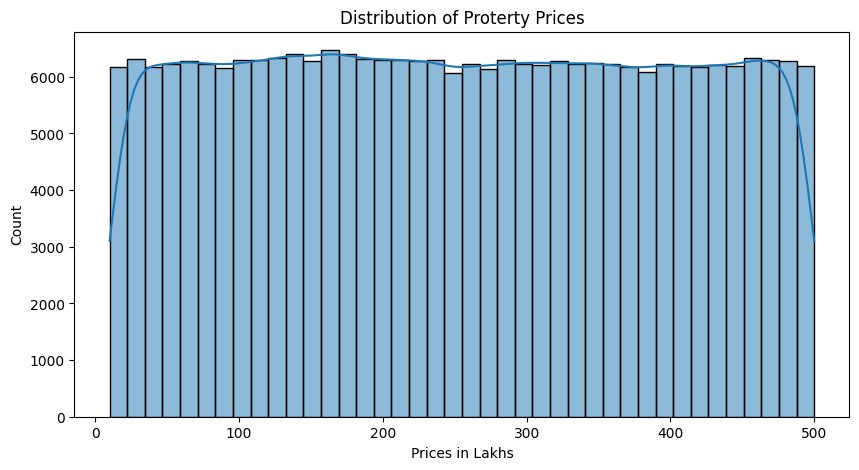

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df["Price_in_Lakhs"], bins=40, kde=True)
plt.title("Distribution of Proterty Prices")
plt.xlabel("Prices in Lakhs")
plt.ylabel("Count")
plt.show()

# Top 10 Cities by Average Property Prices

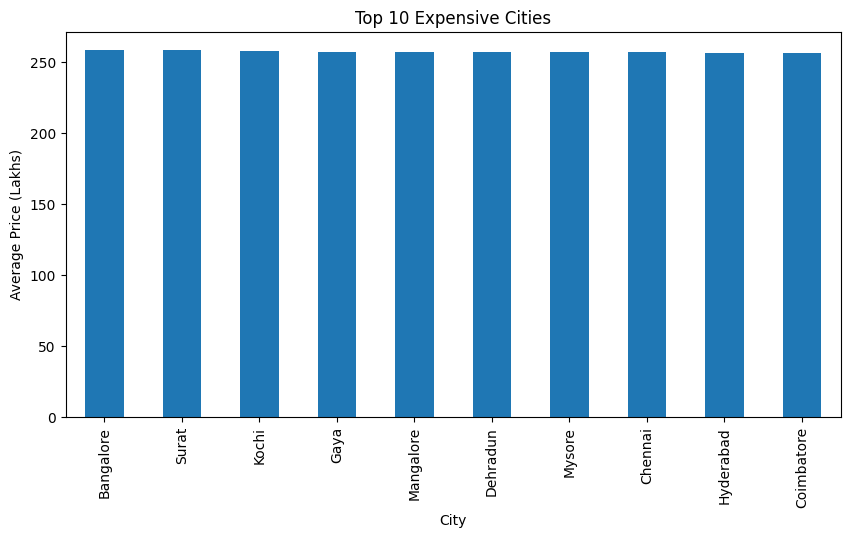

In [10]:
top_cities = df.groupby("City")["Price_in_Lakhs"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_cities.plot(kind="bar")
plt.title("Top 10 Expensive Cities")
plt.ylabel("Average Price (Lakhs)")
plt.show()

# Correlation Heatmap


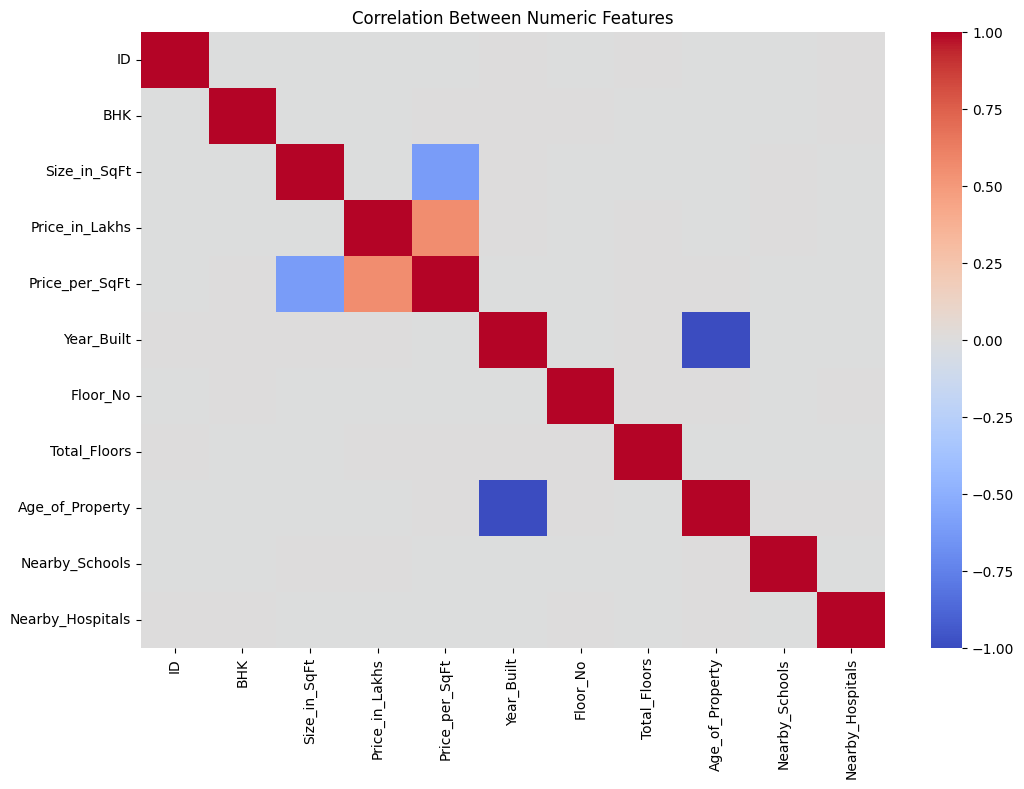

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm")
plt.title("Correlation Between Numeric Features")
plt.show()


# Feature Engineering
 To improve model performance, we created additional business-relevant features

 - Future property price after 5 years
 - Good investment indicator
 - Luxury property flag
 - Spacious property flag

 These engineered features help transform raw housing data into decision- making signals.


In [12]:
df["Future_Price_5Y"] = df["Price_in_Lakhs"] * (1.08 ** 5)

df["Good_Investment"] = np.where(
    df["Future_Price_5Y"] > df["Price_in_Lakhs"] * 1.35, 1, 0
)

df["Luxury_Property"] = np.where(df["Price_in_Lakhs"] > 150, 1, 0)

df["Spacious_Property"] = np.where(df["Size_in_SqFt"] > 1800, 1, 0)

df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status,Future_Price_5Y,Good_Investment,Luxury_Property,Spacious_Property
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move,719.618119,1,1,1
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction,287.283026,1,1,1
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move,270.047807,1,1,1
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move,441.224528,1,1,1
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move,268.740105,1,1,1


# Model 1: Investment Classification

Goal: Predict whether a property is a good investment (1) or Not (0)

In [14]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

cat_cols = df_model.select_dtypes(include=["object"]).columns

le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le

In [15]:
X_cls = df_model.drop(columns=["ID","Good_Investment","Future_Price_5Y"])
y_cls = df_model["Good_Investment"]

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [17]:
acc = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(acc,4))
print("F1 Score:", round(f1,4))

Accuracy: 1.0
F1 Score: 1.0


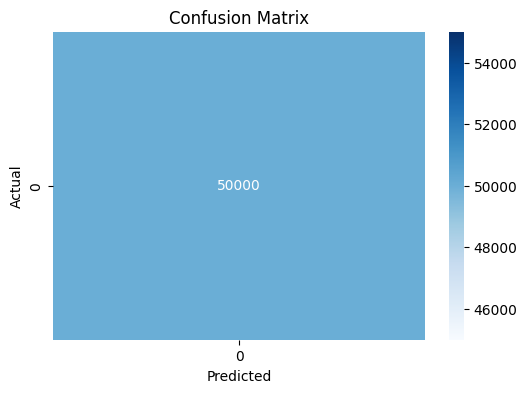

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model 2: Future Price Prediction
Goal: Predict property value after 5 years

In [19]:
X_reg = df_model.drop(columns=["ID","Good_Investment","Future_Price_5Y"])
y_reg = df_model["Future_Price_5Y"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [20]:
from sklearn.ensemble import RandomForestRegressor

reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

reg.fit(X_train_r, y_train_r)
pred_r = reg.predict(X_test_r)

In [21]:
mae = mean_absolute_error(y_test_r, pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, pred_r))
r2 = r2_score(y_test_r, pred_r)

print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2 Score:", round(r2,4))

MAE: 0.03
RMSE: 0.04
R2 Score: 1.0


# Model Performance Summary

In [22]:
summary = pd.DataFrame({
    "Task": ["Classification", "Regression"],
    "Model": ["Random Forest Classifier", "Random Forest Regressor"],
    "Metric 1": [f"Accuracy: {round(acc,4)}", f"MAE: {round(mae,2)}"],
    "Metric 2": [f"F1 Score: {round(f1,4)}", f"RMSE: {round(rmse,2)}"],
    "Metric 3": ["-", f"R2 Score: {round(r2,4)}"]
})

summary

,Task,Model,Metric 1,Metric 2,Metric 3
0,Classification,Random Forest Classifier,Accuracy: 1.0,F1 Score: 1.0,-
1,Regression,Random Forest Regressor,MAE: 0.03,RMSE: 0.04,R2 Score: 1.0


# Key Insights

### Market Observations
- Property prices vary significantly across cities and states.
- Larger properties generally command higher prices.
- Premium furnished homes show higher market valuation.
- Cities with higher demand clusters indicate better appreciation potential.

### Investment Insights
- Properties with balanced price, size, and location often outperform overpriced insights.
- Spacious mid-range homes offer strong long-term ROI potential.
- Luxury homes provide ticket appreciation but carry higher entry risk.

# 💼 Business Recommendations

### For Individual Investors

- Focus on growing urban cities with moderate current pricing.
- Prioritize spacious and well-connected properties.
- Use future price prediction before purchasing.

### For Real Estate Companies

- Use predictive pricing for inventory strategy.
- Identify cities with rising demand for expansion.
- Recommend investment-grade properties to clients.

### For Buyers

- Avoid emotionally driven purchases.
- Compare expected appreciation with current valuation.

# ✅ Conclusion

This project successfully demonstrates how Machine Learning can transform traditional real estate decision-making into a data-driven process.

The system predicts:

1. Whether a property is a good investment  
2. Estimated future price after 5 years

It combines analytics, predictive intelligence, and deployment into a practical real-world solution.

# 🚀 Future Scope

- Integrate live property listing APIs
- Add sentiment analysis from market news
- Include loan EMI / mortgage planning
- Add location heatmaps using GIS
- Test Deep Learning models (GRU / Transformer)
- Personalized investment recommendation engine